# Toy6 — Modelamiento MT con SimPEG

Modelamiento directo magnetotelúrico del modelo **Toy6** con SimPEG
(`NSEM.Simulation3DPrimarySecondary`, formulación primario–secundario).

Es la respuesta de referencia contra la que se compara el operador propio del repositorio. Usa la
misma malla, el mismo modelo de conductividad, las mismas frecuencias y el mismo receptor que
`MT_ModelToy6_MT3DZ.ipynb`.

**Genera:** `impedance_SimPEG_Toy6.npy`, `tipper_SimPEG_Toy6.npy` y la figura `SimPEG_Toy6.png`.

In [1]:
# 0) Importaciones
import numpy as np
import discretize
import matplotlib.pyplot as plt

from simpeg.electromagnetics import natural_source as NSEM

In [2]:
# 1) Malla, modelo de conductividad, frecuencias y receptor

# Frecuencias del modelamiento (Hz)
frequency_list = np.logspace(-4, 2, 3)

# Ubicacion del receptor (x, y, z) en metros
rx_loc = np.array([
    [0.0, 0.0, -53.7],
])

# Malla y modelo 3D de conductividad (sigma en S/m; las celdas de aire valen 1e-8)
mesh = discretize.utils.load_mesh("../../../../models/Toy6/mesh_Toy6_MT.json")
sigma = np.load("../../../../models/Toy6/model_Toy6_MT.npy", allow_pickle=True)

# Modelo primario (background): semiespacio de 2e-3 S/m conservando las celdas de aire
sigBG = np.ones(mesh.nC) * 2e-3
air_cells = np.isclose(sigma, 1e-8)
sigBG[air_cells] = 1e-8

print("mesh  =", mesh)
print("nC    =", mesh.nC)
print("nEx, nEy, nEz =", mesh.nEx, mesh.nEy, mesh.nEz)
print("frecuencias   =", frequency_list)
print("receptores    =", rx_loc)

mesh  = 
  TensorMesh: 27,000 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     30     -7,850.00      7,850.00    250.00  1,800.00    7.20
   y     30     -7,850.00      7,850.00    250.00  1,800.00    7.20
   z     30     -9,000.00      5,000.00    200.00  1,000.00    5.00


nC    = 27000
nEx, nEy, nEz = 28830 28830 28830
frecuencias   = [1.e-04 1.e-01 1.e+02]
receptores    = [[  0.    0.  -53.7]]


In [3]:
# 2) Survey: impedancia y tipper complejos en el receptor

receiver_list = []

# Impedancia: partes real e imaginaria de las cuatro componentes
for rx_orientation in ["xx", "xy", "yx", "yy"]:
    receiver_list.append(
        NSEM.Rx.Impedance(rx_loc, orientation=rx_orientation, component="real")
    )
    receiver_list.append(
        NSEM.Rx.Impedance(rx_loc, orientation=rx_orientation, component="imag")
    )

# Tipper: partes real e imaginaria de Tzx y Tzy
for rx_orientation in ["zx", "zy"]:
    receiver_list.append(
        NSEM.Rx.Tipper(rx_loc, orientation=rx_orientation, component="real")
    )
    receiver_list.append(
        NSEM.Rx.Tipper(rx_loc, orientation=rx_orientation, component="imag")
    )

# Una fuente de onda plana por frecuencia
source_list = [
    NSEM.Src.PlanewaveXYPrimary(receiver_list, freq)
    for freq in frequency_list
]

survey = NSEM.Survey(source_list)

print("Fuentes (frecuencias):", len(source_list))
print("Receptores por fuente:", len(receiver_list))

Fuentes (frecuencias): 3
Receptores por fuente: 12


In [4]:
# 3) Modelamiento directo con SimPEG
problem = NSEM.Simulation3DPrimarySecondary(
    mesh=mesh,
    survey=survey,
    sigma=sigma,
    sigmaPrimary=sigBG,
    forward_only=True,
)

dobs = problem.dpred()
data = NSEM.Data(survey=survey, dobs=dobs)

print("Datos calculados:", dobs.size,
      "=", rx_loc.shape[0], "receptores x", len(receiver_list), "componentes x",
      len(source_list), "frecuencias")

/home/sebas-al/miniconda3/envs/inversionprofsergio_torch/lib/python3.11/site-packages/simpeg/simulation.py:197: DefaultSolverWarning: Using the default solver: Pardiso. 

If you would like to suppress this notification, add 
warnings.filterwarnings('ignore', simpeg.utils.solver_utils.DefaultSolverWarning)
 to your script.
  return get_default_solver(warn=True)


Datos calculados: 36 = 1 receptores x 12 componentes x 3 frecuencias


In [5]:
# 4) Reensamblado de la respuesta compleja y exportacion
#    Z: (n_rec, n_freq, 2, 2)   T: (n_rec, n_freq, 2)   mismo formato que el operador MT3DZ
n_rec = rx_loc.shape[0]
n_freq = len(frequency_list)

impedance_simpeg = np.zeros((n_rec, n_freq, 2, 2), dtype=complex)
tipper_simpeg = np.zeros((n_rec, n_freq, 2), dtype=complex)

for ifreq, src in enumerate(survey.source_list):
    # Cada receptor de la lista aporta una parte real o imaginaria
    zxx = np.asarray(data[src, receiver_list[0]]) + 1j * np.asarray(data[src, receiver_list[1]])
    zxy = np.asarray(data[src, receiver_list[2]]) + 1j * np.asarray(data[src, receiver_list[3]])
    zyx = np.asarray(data[src, receiver_list[4]]) + 1j * np.asarray(data[src, receiver_list[5]])
    zyy = np.asarray(data[src, receiver_list[6]]) + 1j * np.asarray(data[src, receiver_list[7]])

    tzx = np.asarray(data[src, receiver_list[8]]) + 1j * np.asarray(data[src, receiver_list[9]])
    tzy = np.asarray(data[src, receiver_list[10]]) + 1j * np.asarray(data[src, receiver_list[11]])

    impedance_simpeg[:, ifreq, 0, 0] = zxx
    impedance_simpeg[:, ifreq, 0, 1] = zxy
    impedance_simpeg[:, ifreq, 1, 0] = zyx
    impedance_simpeg[:, ifreq, 1, 1] = zyy

    tipper_simpeg[:, ifreq, 0] = tzx
    tipper_simpeg[:, ifreq, 1] = tzy

# El orden de survey.source_list sigue el de frequency_list, asi que los ejes ya coinciden
np.save("impedance_SimPEG_Toy6.npy", impedance_simpeg)
np.save("tipper_SimPEG_Toy6.npy", tipper_simpeg)

print("Z:", impedance_simpeg.shape, "| T:", tipper_simpeg.shape)

Z: (1, 3, 2, 2) | T: (1, 3, 2)


In [6]:
# 5) Resistividad aparente, fase y tipper
mu_0 = 4 * np.pi * 1e-7


def apparent_resistivity(Zcomp, frequencies):
    """Resistividad aparente a partir de una componente de Z, forma (n_rec, n_freq)."""
    omega = 2 * np.pi * np.asarray(frequencies)[None, :]
    return np.abs(Zcomp) ** 2 / (mu_0 * omega)


def phase_deg(Zcomp):
    """Fase en grados."""
    return np.degrees(np.angle(Zcomp))


Zxy = impedance_simpeg[:, :, 0, 1]
Zyx = impedance_simpeg[:, :, 1, 0]

rho_xy = apparent_resistivity(Zxy, frequency_list)
rho_yx = apparent_resistivity(Zyx, frequency_list)

phi_xy = phase_deg(Zxy)
phi_yx = phase_deg(Zyx)

Tzx = tipper_simpeg[:, :, 0]
Tzy = tipper_simpeg[:, :, 1]

mag_tzx, mag_tzy = np.abs(Tzx), np.abs(Tzy)
phi_tzx, phi_tzy = phase_deg(Tzx), phase_deg(Tzy)

irec = 0
print(f"{'f [Hz]':>10} | {'rho_xy':>12} {'rho_yx':>12} | {'phi_xy':>9} {'phi_yx':>9} |"
      f" {'|Tzx|':>9} {'|Tzy|':>9}")
print("-" * 84)
for j, f in enumerate(frequency_list):
    print(f"{f:10.1e} | {rho_xy[irec, j]:12.4f} {rho_yx[irec, j]:12.4f} |"
          f" {phi_xy[irec, j]:9.3f} {phi_yx[irec, j]:9.3f} |"
          f" {mag_tzx[irec, j]:9.5f} {mag_tzy[irec, j]:9.5f}")

    f [Hz] |       rho_xy       rho_yx |    phi_xy    phi_yx |     |Tzx|     |Tzy|
------------------------------------------------------------------------------------
   1.0e-04 |     265.5008     277.8208 |  -134.961    45.059 |   0.00002   0.00015
   1.0e-01 |     272.2150     293.9563 |  -134.478    46.308 |   0.01316   0.00491
   1.0e+02 |     438.0139     552.5407 |  -130.906    48.153 |   0.11350   0.08561


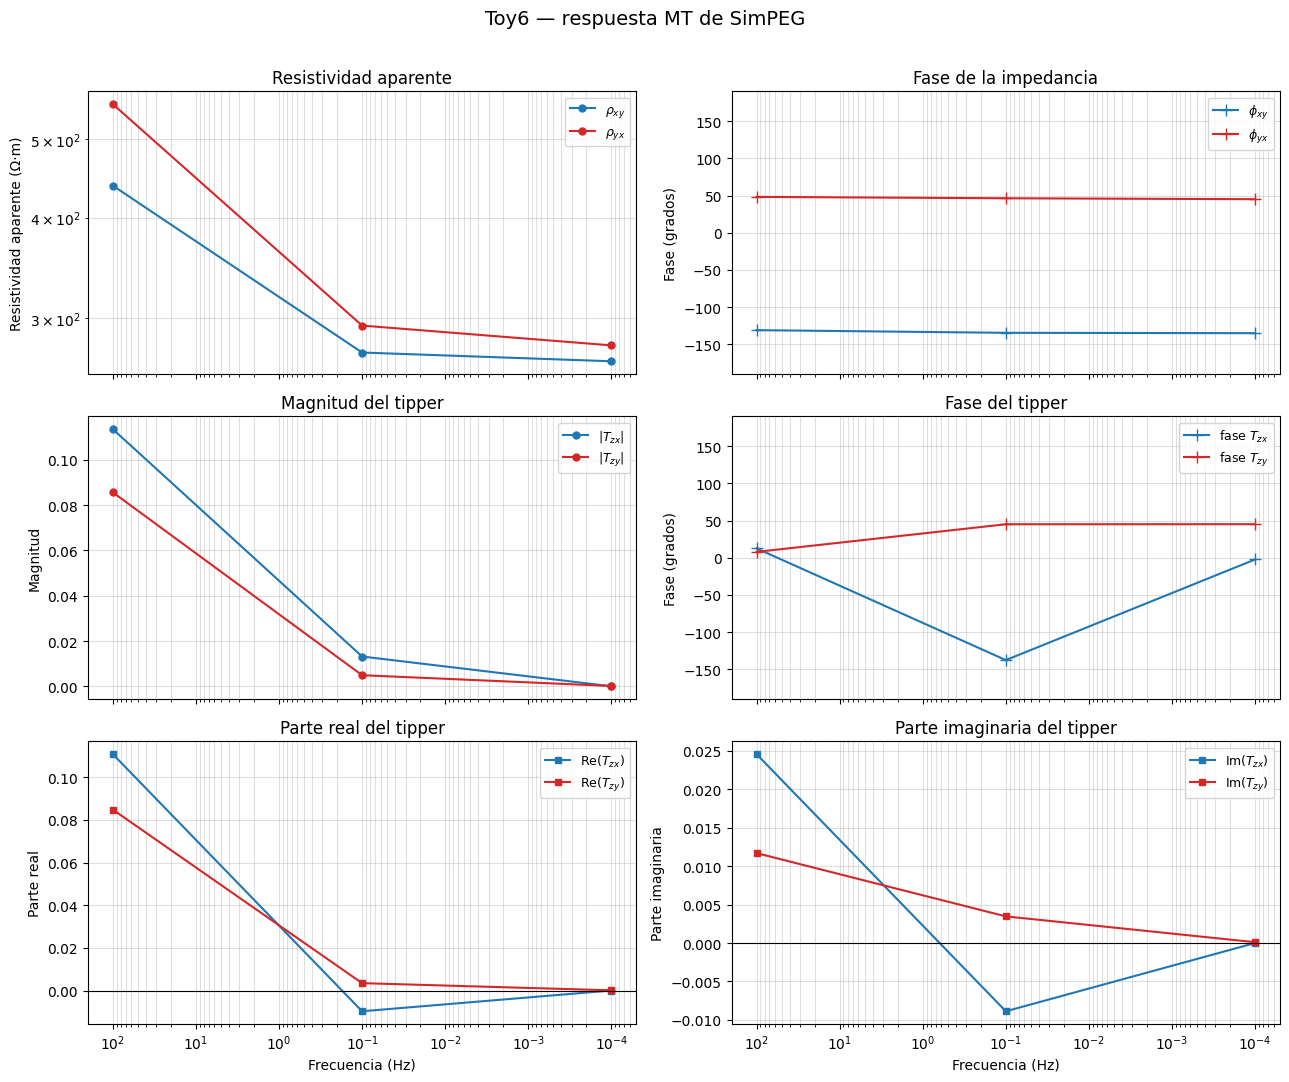

In [7]:
# 6) Figura unica: resistividad aparente, fase y tipper (SimPEG)
irec = 0
frec = frequency_list

c_xy, c_yx = "tab:blue", "tab:red"

fig, axes = plt.subplots(3, 2, figsize=(13, 11), sharex=True)
(ax_rho, ax_phi), (ax_tmag, ax_tphi), (ax_treal, ax_timag) = axes

# --- Resistividad aparente
ax_rho.plot(frec, rho_xy[irec], "-o", color=c_xy, markersize=5, label=r"$\rho_{xy}$")
ax_rho.plot(frec, rho_yx[irec], "-o", color=c_yx, markersize=5, label=r"$\rho_{yx}$")
ax_rho.set_yscale("log")
ax_rho.set_ylabel("Resistividad aparente (Ω·m)")
ax_rho.set_title("Resistividad aparente")

# --- Fase de la impedancia
ax_phi.plot(frec, phi_xy[irec], "-+", color=c_xy, markersize=9, label=r"$\phi_{xy}$")
ax_phi.plot(frec, phi_yx[irec], "-+", color=c_yx, markersize=9, label=r"$\phi_{yx}$")
ax_phi.set_ylim(-190, 190)
ax_phi.set_ylabel("Fase (grados)")
ax_phi.set_title("Fase de la impedancia")

# --- Magnitud del tipper
ax_tmag.plot(frec, mag_tzx[irec], "-o", color=c_xy, markersize=5, label=r"$|T_{zx}|$")
ax_tmag.plot(frec, mag_tzy[irec], "-o", color=c_yx, markersize=5, label=r"$|T_{zy}|$")
ax_tmag.set_ylabel("Magnitud")
ax_tmag.set_title("Magnitud del tipper")

# --- Fase del tipper
ax_tphi.plot(frec, phi_tzx[irec], "-+", color=c_xy, markersize=9, label=r"fase $T_{zx}$")
ax_tphi.plot(frec, phi_tzy[irec], "-+", color=c_yx, markersize=9, label=r"fase $T_{zy}$")
ax_tphi.set_ylim(-190, 190)
ax_tphi.set_ylabel("Fase (grados)")
ax_tphi.set_title("Fase del tipper")

# --- Parte real e imaginaria del tipper
ax_treal.plot(frec, np.real(Tzx[irec]), "-s", color=c_xy, markersize=4, label=r"Re($T_{zx}$)")
ax_treal.plot(frec, np.real(Tzy[irec]), "-s", color=c_yx, markersize=4, label=r"Re($T_{zy}$)")
ax_treal.set_ylabel("Parte real")
ax_treal.set_title("Parte real del tipper")

ax_timag.plot(frec, np.imag(Tzx[irec]), "-s", color=c_xy, markersize=4, label=r"Im($T_{zx}$)")
ax_timag.plot(frec, np.imag(Tzy[irec]), "-s", color=c_yx, markersize=4, label=r"Im($T_{zy}$)")
ax_timag.set_ylabel("Parte imaginaria")
ax_timag.set_title("Parte imaginaria del tipper")

for ax in axes.ravel():
    ax.set_xscale("log")
    ax.grid(True, which="both", alpha=0.4)
    ax.legend(loc="best", fontsize=9)

for ax in (ax_treal, ax_timag):
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Frecuencia (Hz)")

# El eje x es compartido: basta invertirlo una vez
ax_rho.invert_xaxis()

fig.suptitle("Toy6 — respuesta MT de SimPEG", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("SimPEG_Toy6.png", dpi=300, bbox_inches="tight")
plt.show()

## Notas

- `Simulation3DPrimarySecondary` resuelve el campo secundario sobre un primario analítico de
  semiespacio (`sigmaPrimary = sigBG`), por eso el modelo de fondo debe conservar las celdas de aire.
- A las frecuencias más bajas ($10^{-4}$ Hz) el *skin depth* supera el tamaño del dominio de
  `mesh_Toy6_MT.json` y la respuesta queda dominada por los bordes de la malla.

### Archivos generados

| Archivo | Contenido |
|---|---|
| `impedance_SimPEG_Toy6.npy` | tensor de impedancias `Z`, forma `(n_rec, n_freq, 2, 2)` |
| `tipper_SimPEG_Toy6.npy` | tipper `T`, forma `(n_rec, n_freq, 2)` |
| `SimPEG_Toy6.png` | resistividad aparente, fase y tipper de SimPEG |